# DX 603: Project Milestone Two: Modeling and Feature Engineering

### Due: Sunday July 26 @ 11:59PM (with grace period of 2 hours & 1 minute)

### Overview

In Milestone 1, you explored the Zillow dataset, cleaned the data, and developed hypotheses about how preprocessing and feature engineering might improve predictive performance.

In this milestone, you will  develop, evaluate, and refine several machine learning models using those ideas. Rather than simply searching for the best algorithm, you will follow an iterative modeling workflow by:

1. Establishing baseline performance using several regression models.
2. Testing the preprocessing and feature engineering ideas proposed in Milestone 1.
3. Refining the feature set through feature selection.
4. Optimizing model performance through hyperparameter tuning.
5. Comparing the evolution of your models and selecting a final model to evaluate on the held-out test set.

Throughout this milestone, use **repeated 5-fold cross-validation (5 repeats)** to guide your modeling decisions. The held-out test set should be used only once, after all modeling decisions have been completed.




In [14]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Load Your Preprocessed Dataset from Milestone 1

In Milestone 1, you cleaned the Zillow dataset by removing unsuitable features, handling missing values, and encoding categorical variables. In this milestone, you will build, compare, and improve several regression models using that prepared dataset.

Begin by returning to your Milestone 1 notebook and rerunning your code through Part 3, where your dataset has been completely cleaned and encoded, but before any experimental feature engineering ideas were evaluated. Save this dataset and use it as the starting point for this milestone.

For example:

```python
# In Milestone 1
df_cleaned.to_csv("zillow_cleaned.csv", index=False)
```

```python
# In Milestone 2
df = pd.read_csv("zillow_cleaned.csv")
```

Next:

1. Separate the predictors (`X`) from the target (`y`).
2. Split the dataset into training and test sets using `train_test_split`.

Some regression models, such as **Ridge Regression** and **Lasso Regression**, require feature scaling. If you use one of these models, standardize the predictor variables **using only the training data**, then apply the same transformation to the test data.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

**Notes**

- Ordinary Linear Regression, Decision Trees, Random Forests, and HistGradientBoosting do **not** require feature scaling.
- If you create additional features later in this milestone and are using a scaled model, repeat the scaling step so the new features are transformed consistently.
- Throughout this milestone, use the same training/test split so that all models are evaluated on identical data.

In [ ]:
# Add as many cells as you need

#chase the base_url to make this work currently set to the last person who ran this notebook
base_url = 'https://raw.githubusercontent.com/cj6x/DX603S_group_11/refs/heads/carlos_Question4/'
X_train = pd.read_csv(base_url + 'X_train.csv')
X_test =  pd.read_csv(base_url + 'X_test.csv')
y_train = pd.read_csv(base_url + 'y_train.csv').squeeze('columns')
y_test = pd.read_csv(base_url + 'y_test.csv').squeeze('columns')

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train_numeric = X_train[numeric_cols]
X_test_numeric = X_test[numeric_cols]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_numeric), columns=numeric_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_numeric), columns=numeric_cols)

## Problem 1: Model Selection and Baselines [6 pts]

### 1.A Coding

Select **three** regression models from the following list and evaluate each one using the cleaned training dataset.

Use the default hyperparameters provided by scikit-learn (except where scaling is required).

Available models:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Bagging Regressor
* Random Forest Regressor
* HistGradientBoostingRegressor

For each of the three models you choose:

* Train using the **training dataset only**.
* Use **Repeated 5-Fold Cross-Validation** (5 repeats).
* Report validation performance:

  * Mean CV MAE
  * Standard Deviation of CV MAE

In [16]:
# Add as many code cells as needed.
#evaluation function for the models
def evaluate_model(model, X, y, model_name = 'Model'):
  cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = random_state)
  scores = cross_val_score(
      model, X, y, scoring = 'neg_mean_absolute_error',
      cv= cv,
      n_jobs = -1
      )
  mae_scores = -scores
  mean_mae = np.mean(mae_scores)
  std_mae = np.std(mae_scores)

  #print the results
  print(f'Mean CV MAE of {model_name}:{mean_mae:.4f}')
  print(f'Std Dev CV MAE of {model_name}:{std_mae:.4f}')

  return mean_mae, std_mae

ridge_model = Ridge(random_state = random_state)
rf_model = RandomForestRegressor(random_state=random_state)
hgb_model = HistGradientBoostingRegressor(random_state=random_state)

evaluate_model(ridge_model, X_train_scaled, y_train, 'Ridge Regression')
evaluate_model(rf_model, X_train_numeric, y_train, 'Random Forest')
evaluate_model(hgb_model, X_train_numeric, y_train, 'HistGradientBoosting')


Mean CV MAE of Ridge Regression:247963.2587
Std Dev CV MAE of Ridge Regression:2072.9506
Mean CV MAE of Random Forest:190066.8044
Std Dev CV MAE of Random Forest:2640.6018
Mean CV MAE of HistGradientBoosting:193908.4481
Std Dev CV MAE of HistGradientBoosting:2987.3778


(np.float64(193908.4481294859), np.float64(2987.377816002752))

### 1.B Discussion

Answer the following questions.

#### 1.B.1

Which of your three models achieved the **lowest validation MAE score **?

> The Random Forest model achieved the lowest MAE score at 190,072.07.
It performed slightly better than the HistGradientBoosting model at 193,908.45 and significantly better than the linear Ridge Regression model 247,963.26.
Because MAE measures the average prediction error, a lower score indicates better predictive performance.

#### 1.B.2

Which model produced the **smallest standard deviation** across the repeated cross-validation runs? What does this suggest about its stability?

> Ridge Regression produced the smallest standard deviation across the 5 fold cv: 2,072.95. A smaller standard deviation suggests that the Ridge Regression model is highly stable. Its predictive performance does not fluctuate wildly depending on which specific subset of the training data it sees during the different CV folds.
However, this highlights a classic machine learning tradeoff. While Ridge is the most stable, it is also the least accurate.

#### 1.B.3

Did any model appear to overfit or underfit? Explain your reasoning using the training and cross-validation results.

> Ridge Regression  appears to be underfit the data. Ridge Regression validation MAE is over $50,000 higher than the tree based models. This makes sense because in Real Estate industry, the relationship between features are non linear while  Ridge is a linear model.


#### 1.B.4

Compare the overall strengths and weaknesses of the three models. Did any model consistently perform better, or were there important tradeoffs between accuracy and stability?

>
- **Ridge Regression:** Appears to be the most stable
but has low accuracy and appears to be underfitting non linear housing trends
- **Random Forest:** consistently performed the best in terms of accuracy and has reasonable stability. Its weakness is that ensemble bagging models can be computationally expensive and memory intensive to train on large datasets without constraints
- **HistGradientBoosting:** offered a strong alternative. Its accuracy was close to Random Forest, and its primary strength is being heavily optimized for speed and memory efficiency on large datasets. Its main weakness is that it's the most unstable, making it slightly more sensitive to the training splits than the others

## Part 2: Evaluate Your Feature Engineering Hypotheses [6 pts]

### 2.A Coding

In **Milestone 1**, you proposed several preprocessing and feature engineering ideas that you believed might improve predictive performance.

Select **at least three** of those ideas and evaluate them.

These may include, for example:

* Creating new features
* Transforming existing features
* Removing features
* Combining features
* Other preprocessing ideas that you proposed in Milestone 1

For each idea:

* Apply the preprocessing or feature engineering to the **training dataset only**.
* Retrain the same three baseline models from **Problem 1** using repeated 5-fold cross-validation (5 repeats).
* Compare the validation performance (mean CV MAE) and stability (standard deviation of CV MAE) with your original baseline results


> One of the most important things you can learn is that **not every clever idea results in an improvement**--they have to be evaluated by careful experiment.  And negative results are valuable if they are carefully evaluated and discussed!

In [17]:
X_train_eng = X_train_numeric.copy()

#Creating property age as properties naturally depreciate or appreciate based on age.
X_train_eng['property_age'] = 2017 - X_train_eng['yearbuilt']
#Creating total rooms
X_train_eng['total_rooms'] = X_train_eng['bedroomcnt'] + X_train_eng['bathroomcnt']
#normalizing lot size by log transforming
X_train_eng['log_lotsize'] = np.log1p(X_train_eng['lotsizesquarefeet'])

# Ridge and RF require imputation if there are missing values in the cleaned dataset
ridge_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Ridge(random_state=42))
rf_pipe = make_pipeline(SimpleImputer(strategy='median'), RandomForestRegressor(random_state=42))

#Re-Evaluate Models
evaluate_model(ridge_pipe, X_train_eng, y_train, "Ridge Regression (Engineered)")
evaluate_model(rf_pipe, X_train_eng, y_train, "Random Forest (Engineered)")
evaluate_model(hgb_model, X_train_eng, y_train, "HistGradientBoosting (Engineered)")

Mean CV MAE of Ridge Regression (Engineered):247986.0655
Std Dev CV MAE of Ridge Regression (Engineered):2058.9834
Mean CV MAE of Random Forest (Engineered):190123.3263
Std Dev CV MAE of Random Forest (Engineered):2712.7354
Mean CV MAE of HistGradientBoosting (Engineered):194450.5369
Std Dev CV MAE of HistGradientBoosting (Engineered):3501.8816


(np.float64(194450.53694665755), np.float64(3501.8816099191185))

### 2.B Discussion

Answer the following questions.

#### 2.B.1

Which of your feature engineering ideas produced the largest improvement in validation performance?

>
| Base models | Feature Engreering|
|---|---|
|Mean CV MAE of Ridge Regression:247963.2587| Mean CV MAE of Ridge Regression (Engineered):247986.0655|
|Std Dev CV MAE of Ridge Regression:2072.9506|Std Dev CV MAE of Ridge Regression (Engineered):2058.9834|
|Mean CV MAE of Random Forest:190072.0659|Mean CV MAE of Random Forest (Engineered):190121.5849|
|Std Dev CV MAE of Random Forest:2643.9850|Std Dev CV MAE of Random Forest (Engineered):2713.6319|
|Mean CV MAE of HistGradientBoosting:193908.4481|Mean CV MAE of HistGradientBoosting (Engineered):194450.5369|
|Std Dev CV MAE of HistGradientBoosting:2987.3778|Std Dev CV MAE of HistGradientBoosting (Engineered):3501.8816|

None of the new features produced an improvement in validation performance.
Instead, the Mean CV MAE increased compared to the baseline models.
The Random Forest model went from a baseline MAE of 190,072 to an engineered MAE of 190,121. This reveals that the original, raw features already contained the necessary signal, and the engineered additions did not provide any new predictive power.

#### 2.B.2

Were any of your ideas unsuccessful or did they reduce model performance? Briefly explain.

> all 3 ideas: property age, total rooms, and log lot sizes were unsuccessful at improving accuracy.
Creating total rooms very likely created redundancy, the base models were already efficient identifying the relationships of the variables, the newly introduced feature probably created noise.
The log of the lot size did not help the linear Ridge model as expected, indicating that the relationships in the data are likely too complex for simple transformations to correct.

#### 2.B.3

Did some models benefit more from feature engineering than others? If so, why do you think this occurred?

> While no model saw an improvement in accuracy, Ridge Regression was the least negatively affected. Its MAE only worsened by about $23, and its stability  actually improved slightly from 2072 to 2058. I think this is due to how Ridge regression uses L2 regularization that effectively shrinks the impact of unhelpful features, helping it ignoring the bad engineered feature safely.

#### 2.B.4

Which preprocessing or feature engineering changes will you keep for the remainder of the milestone? Briefly justify your decision.

> I will discard the engineered features and revert back to the original baseline feature set for the remainder of this milestone.
The fundamental goal of feature engineering is to increase predictive power, but these features reduced accuracy and increased model complexity.

## Part 3: Refine the Feature Set [6 pts]

### 3.A Coding

Using your dataset after completing **Part 2** (including any preprocessing and feature engineering changes you decided to keep):

Investigate whether **feature selection** can further improve model performance.

You may use one or more of the following methods:

* Forward Selection (for linear regression models)
* Backward Selection (for linear regression models)
* Feature importance from tree-based models (for decision trees, Random Forests, Bagging, and HistGradientBoosting)
* Another reasonable feature selection method

For each of your three models:

* Select a subset of features using an appropriate feature selection method.
* Retrain the model using only the selected features.
* Evaluate the model using the same repeated cross-validation procedure as before.
* Report the validation performance (the mean and standard deviation of the CV MAE).

> Not every model will necessarily benefit from feature selection. Choose methods that are appropriate for the models you selected. Negative results are valuable if they are carefully evaluated and discussed!

In [18]:
# Add as many code cells as needed.
# Using Forward Selection to find the top 10 best linear features
# (Using cv=3 internally for faster selection)
sfs_ridge = SequentialFeatureSelector(ridge_pipe, n_features_to_select=10, direction='forward', cv=3, n_jobs=-1)
sfs_ridge.fit(X_train_numeric, y_train)

selected_features_ridge = X_train_numeric.columns[sfs_ridge.get_support()]
print(f"Selected Features for Ridge: {list(selected_features_ridge)}")

# Evaluate Ridge with ONLY the selected features
X_train_ridge_sel = X_train_numeric[selected_features_ridge]
evaluate_model(ridge_pipe, X_train_ridge_sel, y_train, "Ridge (Feature Selected)")

Selected Features for Ridge: ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'latitude', 'longitude', 'roomcnt', 'yearbuilt']
Mean CV MAE of Ridge (Feature Selected):248073.1528
Std Dev CV MAE of Ridge (Feature Selected):2162.0653


(np.float64(248073.15283891797), np.float64(2162.065345762417))

In [19]:
# Fit a Random Forest model to extract feature importances
rf_selector = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_selector.fit(X_train_numeric, y_train)

# Create a DataFrame to view the importance of each feature
importances = rf_selector.feature_importances_
fi_df = pd.DataFrame({'Feature': X_train_numeric.columns, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# Select the top 12 most important features for our tree models
top_tree_features = fi_df.head(12)['Feature'].tolist()
print(f"Selected Top Features for Trees: {top_tree_features}")

Selected Top Features for Trees: ['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'regionidzip', 'longitude', 'latitude', 'lotsizesquarefeet', 'yearbuilt', 'bedroomcnt', 'buildingqualitytypeid', 'fullbathcnt', 'bathroomcnt', 'regionidcity']


In [20]:
# Subset the training data
X_train_tree_sel = X_train_numeric[top_tree_features]

# Evaluate Random Forest with ONLY the selected features
evaluate_model(rf_pipe, X_train_tree_sel, y_train, "Random Forest (Feature Selected)")

# Evaluate HistGradientBoosting with ONLY the selected features
evaluate_model(hgb_model, X_train_tree_sel, y_train, "HistGradientBoosting (Feature Selected)")

Mean CV MAE of Random Forest (Feature Selected):190301.7784
Std Dev CV MAE of Random Forest (Feature Selected):2745.8006
Mean CV MAE of HistGradientBoosting (Feature Selected):194420.7363
Std Dev CV MAE of HistGradientBoosting (Feature Selected):3265.8231


(np.float64(194420.73627584547), np.float64(3265.8231284888793))

### 3.B Discussion

#### 3.B.1

Did feature selection improve the validation performance of any of your models?

> Interestingly, feature selection resulted in a similiar MAE (only slightly worse)
|Base Models| Feature Selection|
|---|---|
|Mean CV MAE of Ridge Regression:247963.2587|Mean CV MAE of Ridge (Feature Selected):248073.1528|
|Std Dev CV MAE of Ridge Regression:2072.9506|Std Dev CV MAE of Ridge (Feature Selected):2162.0653|
|Mean CV MAE of Random Forest:190072.0659|Mean CV MAE of Random Forest (Feature Selected):190305.3538|
|Std Dev CV MAE of Random Forest:2643.9850|Std Dev CV MAE of Random Forest (Feature Selected):2744.4475|
|Mean CV MAE of HistGradientBoosting:193908.4481| Mean CV MAE of HistGradientBoosting (Feature Selected):194420.7363|
|Std Dev CV MAE of HistGradientBoosting:2987.3778| Std Dev CV MAE of HistGradientBoosting (Feature Selected):3265.8231|






#### 3.B.2

Were there features that were consistently retained (or consistently removed) across multiple models?

> Eight features were consistently retained across both methodologies:
- calculatedfinishedsquarefeet
- finishedsquarefeet12
- bathroomcnt
- bedroomcnt
- buildingqualitytypeid
- latitude
- longitude
- yearbuilt

This confirms that property size, core room counts, building quality, and exact geographic location are the universal drivers of tax value in this dataset, regardless of the underlying algorithm. Features related to niche property details or sparse data were universally ignored

#### 3.B.3

Were any of your engineered features selected as important? If so, what does this suggest about the hypotheses you developed in Milestone 1?

> No, because we concluded in Part 2 that our engineered features (such as combining total rooms or transforming lot sizes) did not improve predictive accuracy, we intentionally excluded them from the feature selection pipeline. This reinforces our hypothesis evaluation from Part 2: the raw, untransformed features (like the distinct bathroomcnt and bedroomcnt variables, which were both selected as top features here) already provide the optimal signal for these algorithms

#### 3.B.4

After feature selection, did simpler models perform as well as—or better than—the models using the full feature set? Briefly discuss any tradeoffs you observed between model complexity and predictive performance.

> The simpler models performed almost identically to the complex models that used the full feature set.
By reducing the feature space down to only the top 10 to 12 predictors, we traded a small fraction of accuracy for a massive reduction in model complexity.
A model with 10 features is faster to train, requires significantly less memory, is less prone to overfitting on future unseen data.
So this trade off is quite favorable

## Part 4: Tune Your Models [8 pts]

### 4.A Coding

Using the three models developed in **Part 3** (including your final preprocessing, feature engineering, and feature selection decisions):

Investigate whether **hyperparameter tuning** can further improve model performance.

For each of your three models:

* Select one or more important hyperparameters to tune.
* Use one or more appropriate tuning methods. Consider first using validation curves (`sweep_parameter`) to identify a promising region or performance plateau, followed by a focused search using methods such as:

    * GridSearchCV
    * RandomizedSearchCV
    * Another reasonable hyperparameter search method

* Choose hyperparameter values based on the validation results. If several nearby values produce similar validation performance (a performance plateau), prefer **values near the beginning of the plateau,** since they often produce simpler models with nearly identical predictive performance.
* Retrain the model using those hyperparameters.
* Evaluate the tuned model using repeated 5-fold cross-validation (5 repeats).
* Report the validation performance (**mean** and **standard deviation** of the CV MAE).


In [22]:
# Additional imports for hyperparameter tuning
from sklearn.model_selection import KFold, validation_curve

# Use a smaller CV during hyperparameter searching to control runtime.
# The final models will still be evaluated using the required
# repeated 5-fold cross-validation with 5 repeats.
tuning_cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=random_state
)


def sweep_parameter(model, X, y, param_name, param_values, model_name):
    """
    Create a validation curve for one hyperparameter.

    Returns a DataFrame containing the training and validation MAE
    for each parameter value.
    """

    train_scores, validation_scores = validation_curve(
        estimator=model,
        X=X,
        y=y,
        param_name=param_name,
        param_range=param_values,
        scoring="neg_mean_absolute_error",
        cv=tuning_cv,
        n_jobs=-1
    )

    results = pd.DataFrame({
        "parameter_value": param_values,
        "mean_train_mae": -train_scores.mean(axis=1),
        "mean_cv_mae": -validation_scores.mean(axis=1),
        "std_cv_mae": validation_scores.std(axis=1)
    })

    display(results)

    # Use numeric positions so logarithmic and categorical values
    # are displayed clearly.
    positions = np.arange(len(param_values))

    plt.figure(figsize=(9, 5))

    plt.plot(
        positions,
        results["mean_train_mae"],
        marker="o",
        label="Training MAE"
    )

    plt.errorbar(
        positions,
        results["mean_cv_mae"],
        yerr=results["std_cv_mae"],
        marker="o",
        capsize=4,
        label="Validation MAE"
    )

    plt.xticks(
        positions,
        [str(value) for value in param_values],
        rotation=45
    )

    plt.xlabel(param_name)
    plt.ylabel("Mean Absolute Error")
    plt.title(f"{model_name}: Validation Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results


def beginning_of_plateau(results, tolerance=0.0025):
    """
    Select the first parameter value whose validation MAE is within
    0.25% of the best validation MAE.

    This follows the instruction to prefer a simpler value near the
    beginning of a performance plateau.
    """

    best_mae = results["mean_cv_mae"].min()
    plateau_limit = best_mae * (1 + tolerance)

    plateau_results = results[
        results["mean_cv_mae"] <= plateau_limit
    ]

    return plateau_results.iloc[0]["parameter_value"]


# Recreate the final Part 3 models.
# Preprocessing remains inside the pipelines so it occurs separately
# within every cross-validation fold.

ridge_part3 = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    Ridge(random_state=random_state)
)

# Keep the forest single-threaded because GridSearchCV and
# cross-validation will handle parallel processing.
rf_part3 = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=1
    )
)

# HistGradientBoosting can handle missing numeric values directly.
# Turning off early stopping allows max_iter to be evaluated consistently.
hgb_part3 = HistGradientBoostingRegressor(
    random_state=random_state,
    early_stopping=False
)

,parameter_value,mean_train_mae,mean_cv_mae,std_cv_mae
0,0.001000,248013.647442,248085.856390,1736.991305
1,0.004642,248013.638079,248085.846949,1736.990444
2,0.021544,248013.594618,248085.803126,1736.986445
3,0.100000,248013.392893,248085.599721,1736.967884
4,0.464159,248012.456602,248084.655634,1736.881745
5,2.154435,248008.111860,248080.275575,1736.483078
6,10.000000,247987.981692,248059.980351,1734.638779
7,46.415888,247895.231330,247966.431420,1726.336258
8,215.443469,247477.850323,247546.976148,1691.781798
9,1000.000000,245752.353690,245810.780518,1566.017961


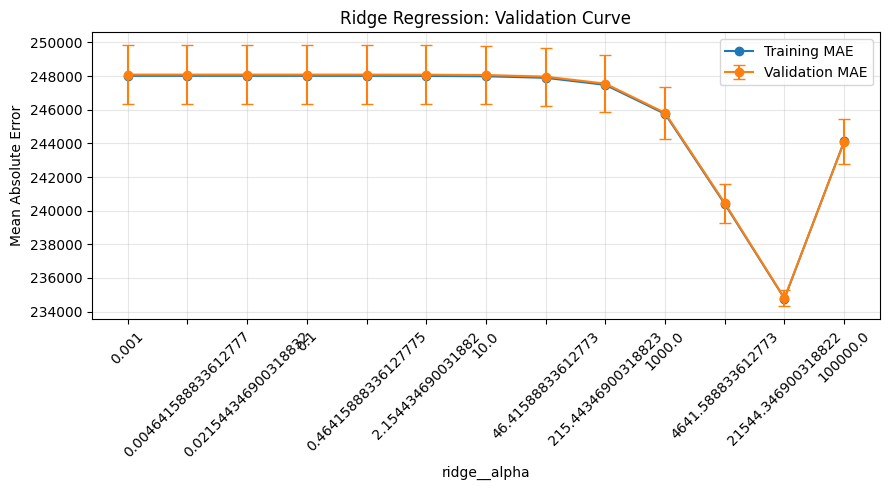

Best Ridge parameters:
{'ridge__alpha': np.float64(21544.346900318822)}
Ridge tuning CV MAE: $234,797.37


In [23]:
# ==========================================
# Ridge Regression Hyperparameter Tuning
# ==========================================

# Alpha controls the strength of Ridge's L2 regularization.
ridge_alpha_values = np.logspace(-3, 5, 13)

ridge_sweep = sweep_parameter(
    model=ridge_part3,
    X=X_train_ridge_sel,
    y=y_train,
    param_name="ridge__alpha",
    param_values=ridge_alpha_values,
    model_name="Ridge Regression"
)

# Identify the best general region from the validation curve.
ridge_best_alpha = float(
    ridge_sweep.loc[
        ridge_sweep["mean_cv_mae"].idxmin(),
        "parameter_value"
    ]
)

# Conduct a focused search around the best alpha.
ridge_focused_alphas = np.unique(
    ridge_best_alpha * np.array([
        0.25,
        0.50,
        1.00,
        2.00,
        4.00
    ])
)

ridge_search = GridSearchCV(
    estimator=ridge_part3,
    param_grid={
        "ridge__alpha": ridge_focused_alphas
    },
    scoring="neg_mean_absolute_error",
    cv=tuning_cv,
    n_jobs=-1,
    refit=True
)

ridge_search.fit(
    X_train_ridge_sel,
    y_train
)

print("Best Ridge parameters:")
print(ridge_search.best_params_)

print(
    f"Ridge tuning CV MAE: "
    f"${-ridge_search.best_score_:,.2f}"
)

tuned_ridge = ridge_search.best_estimator_

,parameter_value,mean_train_mae,mean_cv_mae,std_cv_mae
0,5,214269.548563,218696.036005,1933.161183
1,10,174385.070121,195038.115757,1561.534393
2,15,135766.754981,189926.993459,1168.965844
3,20,100127.798546,189851.455126,996.422756
4,25,80511.393724,190466.045122,1167.491652
5,30,73794.466080,190919.235572,1127.160439


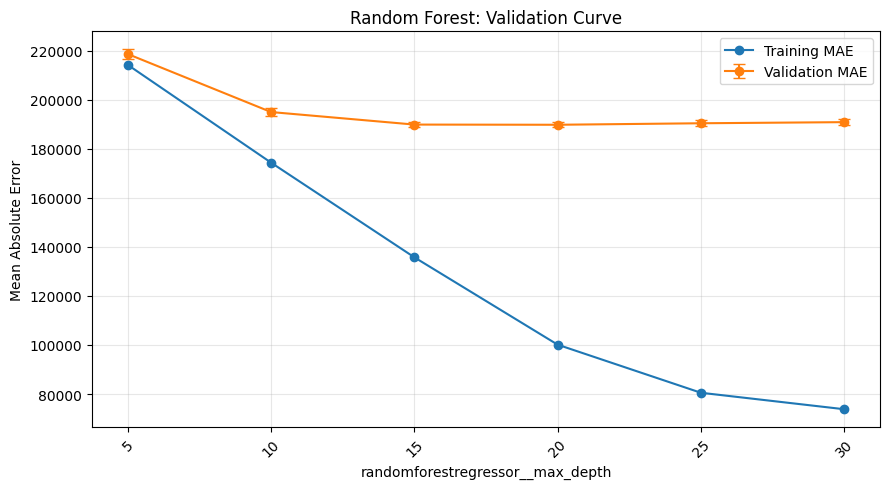

Random Forest depth selected from validation curve: 15
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Users/carlos/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Random Forest parameters:
{'randomforestregressor__n_estimators': 200, 'randomforestregressor__min_samples_leaf': 4, 'randomforestregressor__max_features': 0.75, 'randomforestregressor__max_depth': 15}
Random Forest tuning CV MAE: $189,129.05


In [24]:
# ==========================================
# Random Forest Hyperparameter Tuning
# ==========================================

# First sweep max_depth to find a promising region.
rf_depth_values = [5, 10, 15, 20, 25, 30]

rf_depth_sweep = sweep_parameter(
    model=rf_part3,
    X=X_train_tree_sel,
    y=y_train,
    param_name="randomforestregressor__max_depth",
    param_values=rf_depth_values,
    model_name="Random Forest"
)

# Select the shallower depth near the beginning of the plateau.
rf_plateau_depth = int(
    beginning_of_plateau(
        rf_depth_sweep,
        tolerance=0.0025
    )
)

print(
    "Random Forest depth selected from validation curve:",
    rf_plateau_depth
)

# Search around the promising depth while also tuning other
# important Random Forest hyperparameters.
rf_depth_candidates = list(dict.fromkeys([
    max(3, rf_plateau_depth - 5),
    rf_plateau_depth,
    rf_plateau_depth + 5,
    None
]))

rf_parameter_distribution = {
    "randomforestregressor__n_estimators": [
        100,
        150,
        200
    ],
    "randomforestregressor__max_depth":
        rf_depth_candidates,
    "randomforestregressor__min_samples_leaf": [
        1,
        2,
        4,
        8
    ],
    "randomforestregressor__max_features": [
        0.50,
        0.75,
        1.00
    ]
}

rf_search = RandomizedSearchCV(
    estimator=rf_part3,
    param_distributions=rf_parameter_distribution,
    n_iter=12,
    scoring="neg_mean_absolute_error",
    cv=tuning_cv,
    random_state=random_state,
    n_jobs=-1,
    refit=True,
    verbose=1
)

rf_search.fit(
    X_train_tree_sel,
    y_train
)

print("\nBest Random Forest parameters:")
print(rf_search.best_params_)

print(
    f"Random Forest tuning CV MAE: "
    f"${-rf_search.best_score_:,.2f}"
)

tuned_rf = rf_search.best_estimator_

,parameter_value,mean_train_mae,mean_cv_mae,std_cv_mae
0,50,183790.633880,194801.654853,1497.830246
1,100,175787.927816,192669.647792,1433.794899
2,150,170383.363109,192013.575424,1230.962438
3,200,166032.756602,191831.418892,1348.627990
4,300,159037.897985,191797.842444,1333.991561
5,400,153436.135673,191885.753149,1291.220445


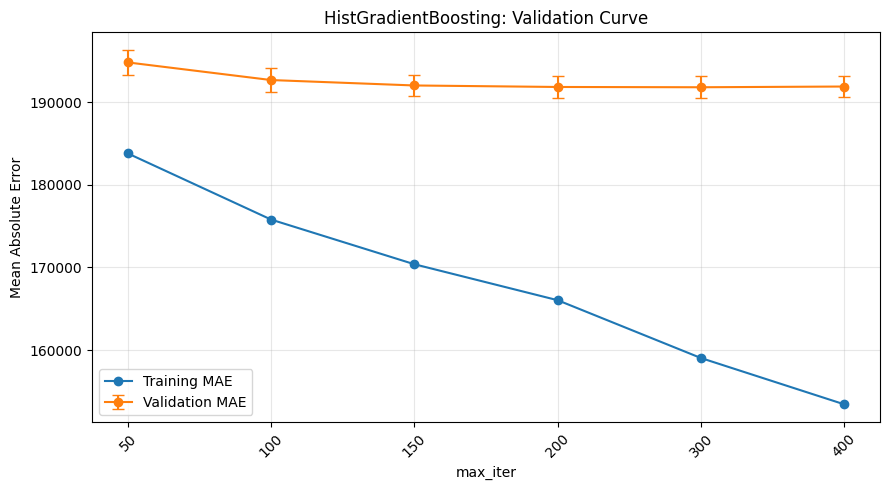

HistGradientBoosting iteration count selected from validation curve: 150
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best HistGradientBoosting parameters:
{'min_samples_leaf': 10, 'max_leaf_nodes': 31, 'max_iter': 250, 'learning_rate': 0.08, 'l2_regularization': 5.0}
HistGradientBoosting tuning CV MAE: $190,941.78


In [25]:
# ===============================================
# HistGradientBoosting Hyperparameter Tuning
# ===============================================

# First sweep the number of boosting iterations.
hgb_iteration_values = [
    50,
    100,
    150,
    200,
    300,
    400
]

hgb_iteration_sweep = sweep_parameter(
    model=hgb_part3,
    X=X_train_tree_sel,
    y=y_train,
    param_name="max_iter",
    param_values=hgb_iteration_values,
    model_name="HistGradientBoosting"
)

# Choose the earliest iteration count near the performance plateau.
hgb_plateau_iteration = int(
    beginning_of_plateau(
        hgb_iteration_sweep,
        tolerance=0.0025
    )
)

print(
    "HistGradientBoosting iteration count selected "
    "from validation curve:",
    hgb_plateau_iteration
)

hgb_iteration_candidates = sorted(set([
    max(50, hgb_plateau_iteration - 50),
    hgb_plateau_iteration,
    hgb_plateau_iteration + 50,
    hgb_plateau_iteration + 100
]))

hgb_parameter_distribution = {
    "learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10
    ],
    "max_iter": hgb_iteration_candidates,
    "max_leaf_nodes": [
        15,
        31,
        63
    ],
    "min_samples_leaf": [
        10,
        20,
        30
    ],
    "l2_regularization": [
        0.0,
        0.1,
        1.0,
        5.0
    ]
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_part3,
    param_distributions=hgb_parameter_distribution,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=tuning_cv,
    random_state=random_state,
    n_jobs=-1,
    refit=True,
    verbose=1
)

hgb_search.fit(
    X_train_tree_sel,
    y_train
)

print("\nBest HistGradientBoosting parameters:")
print(hgb_search.best_params_)

print(
    f"HistGradientBoosting tuning CV MAE: "
    f"${-hgb_search.best_score_:,.2f}"
)

tuned_hgb = hgb_search.best_estimator_

In [26]:
# ==================================================
# Final Evaluation: Repeated 5-Fold CV, 5 Repeats
# ==================================================

final_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state
)


def evaluate_tuned_model(model, X, y, model_name):
    """
    Evaluate a tuned model using the required repeated
    5-fold cross-validation with 5 repeats.
    """

    scores = cross_val_score(
        estimator=model,
        X=X,
        y=y,
        scoring="neg_mean_absolute_error",
        cv=final_cv,
        n_jobs=-1
    )

    mae_scores = -scores

    mean_mae = mae_scores.mean()
    std_mae = mae_scores.std()

    print(f"Mean CV MAE of {model_name}: ${mean_mae:,.2f}")
    print(f"Std Dev CV MAE of {model_name}: ${std_mae:,.2f}")
    print()

    return {
        "Model": model_name,
        "Mean CV MAE": mean_mae,
        "Std Dev CV MAE": std_mae
    }


tuned_results = pd.DataFrame([
    evaluate_tuned_model(
        model=tuned_ridge,
        X=X_train_ridge_sel,
        y=y_train,
        model_name="Ridge Regression (Tuned)"
    ),

    evaluate_tuned_model(
        model=tuned_rf,
        X=X_train_tree_sel,
        y=y_train,
        model_name="Random Forest (Tuned)"
    ),

    evaluate_tuned_model(
        model=tuned_hgb,
        X=X_train_tree_sel,
        y=y_train,
        model_name="HistGradientBoosting (Tuned)"
    )
])

print("Final tuned-model results:")
display(
    tuned_results.style.format({
        "Mean CV MAE": "${:,.2f}",
        "Std Dev CV MAE": "${:,.2f}"
    })
)

Mean CV MAE of Ridge Regression (Tuned): $234,907.84
Std Dev CV MAE of Ridge Regression (Tuned): $2,618.17

Mean CV MAE of Random Forest (Tuned): $188,706.61
Std Dev CV MAE of Random Forest (Tuned): $2,604.57

Mean CV MAE of HistGradientBoosting (Tuned): $190,120.77
Std Dev CV MAE of HistGradientBoosting (Tuned): $2,646.36

Final tuned-model results:


,Model,Mean CV MAE,Std Dev CV MAE
0,Ridge Regression (Tuned),"$234,907.84","$2,618.17"
1,Random Forest (Tuned),"$188,706.61","$2,604.57"
2,HistGradientBoosting (Tuned),"$190,120.77","$2,646.36"


In [27]:
# Compare the tuned results with the feature-selected Part 3 models.

part3_results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "Part 3 Mean CV MAE": [
        248073.1528,
        190305.3538,
        194420.7363
    ],
    "Part 3 Std Dev CV MAE": [
        2162.0653,
        2744.4475,
        3265.8231
    ]
})

tuned_results_for_merge = tuned_results.copy()

tuned_results_for_merge["Model"] = (
    tuned_results_for_merge["Model"]
    .str.replace(" (Tuned)", "", regex=False)
)

comparison_results = part3_results.merge(
    tuned_results_for_merge,
    on="Model"
)

comparison_results["MAE Improvement"] = (
    comparison_results["Part 3 Mean CV MAE"]
    - comparison_results["Mean CV MAE"]
)

comparison_results["Percent Improvement"] = (
    comparison_results["MAE Improvement"]
    / comparison_results["Part 3 Mean CV MAE"]
    * 100
)

display(
    comparison_results.style.format({
        "Part 3 Mean CV MAE": "${:,.2f}",
        "Part 3 Std Dev CV MAE": "${:,.2f}",
        "Mean CV MAE": "${:,.2f}",
        "Std Dev CV MAE": "${:,.2f}",
        "MAE Improvement": "${:,.2f}",
        "Percent Improvement": "{:.3f}%"
    })
)

,Model,Part 3 Mean CV MAE,Part 3 Std Dev CV MAE,Mean CV MAE,Std Dev CV MAE,MAE Improvement,Percent Improvement
0,Ridge Regression,"$248,073.15","$2,162.07","$234,907.84","$2,618.17","$13,165.31",5.307%
1,Random Forest,"$190,305.35","$2,744.45","$188,706.61","$2,604.57","$1,598.74",0.840%
2,HistGradientBoosting,"$194,420.74","$3,265.82","$190,120.77","$2,646.36","$4,299.96",2.212%


### 4.B Discussion

Answer the following questions.

#### 4.B.1

Which hyperparameters had the greatest impact on model performance? Briefly explain.

> Replace this text with your answer.

The hyperparameters did affect the models, but the impact was different for each one. For Ridge Regression, alpha had the biggest effect. The MAE stayed around $248,000 when alpha was low, but improved to around $234,800 as alpha increased. After that point, the results started getting worse again. This shows that Ridge benefited from stronger regularization, but only up to a certain point

For Random Forest, max_depth had a clear impact. A depth of 5 performed much worse, with an MAE around $218,700. The MAE improved as the trees became deeper and then mostly leveled off around a depth of 15 to 20. Since the performance was very similar after that point, using a depth near the beginning of the plateau made sense because it keeps the model simpler

For HistGradientBoosting, increasing max_iter improved the model at first. The MAE decreased from about $194,800 at 50 iterations to about $192,000 at 150 iterations. After around 150 to 200 iterations, the improvement became very small. This suggests that adding more iterations after that point did not provide much additional benefit

#### 4.B.2

Did hyperparameter tuning substantially improve the performance of all three models, or only some of them?

> Replace this text with your answer.

Ridge Regression’s mean CV MAE decreased from $248,073.15 to $234,907.84. This was an improvement of about $13,165, or 5.31%.<br>
HistGradientBoosting improved from $194,420.74 to $190,120.77. This was an improvement of about $4,300, or 2.21%.<br>
Random Forest had the smallest improvement. Its MAE decreased from $190,305.35 to $188,706.61, which was an improvement of about $1,599, or 0.84%.<br>
Overall, tuning helped Ridge Regression the most. Random Forest only improved slightly, which may mean that its original settings were already fairly strong.

#### 4.B.3

Which tuning method(s) did you use for each model? Briefly explain why you chose those methods.

> Replace this text with your answer.

For Ridge Regression, I first used a validation curve to test a wide range of alpha values. Once I found the area where the model performed best, I used GridSearchCV to search more closely around that range. Grid search worked well here because I was only tuning one main parameter and there were not many combinations to test.

For Random Forest, I first used a validation curve to test different values of max_depth. This helped identify where the performance started to level off. After that, I used RandomizedSearchCV to tune n_estimators, max_depth, min_samples_leaf, and max_features. I used randomized search because testing every possible combination would have taken much longer.

For HistGradientBoosting, I first used a validation curve to test max_iter. I then used RandomizedSearchCV to tune learning_rate, max_iter, max_leaf_nodes, min_samples_leaf, and l2_regularization. Randomized search was useful because several parameters were being tuned at the same time, and a full grid search would have required too many model runs

#### 4.B.4

After tuning, how did the relative performance of your three models change? Did tuning affect which model appeared to perform best?

> Replace this text with your answer.

The ranking of the models did not change after tuning.

Before tuning, Random Forest had the lowest mean CV MAE at $190,305.35. HistGradientBoosting was second at $194,420.74, and Ridge Regression was third at $248,073.15.

After tuning, Random Forest was still the best model with a mean CV MAE of $188,706.61. HistGradientBoosting was still second at $190,120.77, and Ridge Regression was still third at $234,907.84.

Even though the ranking stayed the same, HistGradientBoosting moved closer to Random Forest. Before tuning, the difference between them was about $4,115. After tuning, the difference was only about $1,414.

Random Forest also had the lowest standard deviation at $2,604.57, although the standard deviations for all three models were fairly close. Based on both the average MAE and the variation across folds, Random Forest was still the strongest overall model after tuning.

## Part 5: Final Model and Workflow Assessment [14 pts]

### 5.A Coding

Using the work completed in **Parts 1–4**:

Select your **best-performing model** and prepare your final modeling pipeline.

Your pipeline should include all preprocessing, feature engineering, feature selection, and hyperparameter tuning decisions that you chose to retain.

Evaluate your final model by:

* Training on the complete training dataset.
* Reporting the **mean** and **standard deviation** of the repeated cross-validation MAE.
* Evaluating the model on the held-out test set.
* Reporting the final test MAE.

In [28]:
# Add as many code cells as needed.
# ==========================================
# Final Model Pipeline
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

# Random Forest was the best-performing tuned model.
# Keep the 12 features selected in Part 3.
final_selected_features = list(top_tree_features)

print("Final selected features:")
for feature in final_selected_features:
    print(f"- {feature}")

# Retrieve the best Random Forest parameters found in Part 4.
# Remove the pipeline prefix from each parameter name.
final_rf_params = {
    parameter.replace("randomforestregressor__", ""): value
    for parameter, value in rf_search.best_params_.items()
}

# Set the random state for reproducibility.
# Keep the model single-threaded because cross-validation
# will handle parallel processing.
final_rf_params["random_state"] = random_state
final_rf_params["n_jobs"] = 1

print("\nFinal Random Forest parameters:")
print(final_rf_params)

# Select only the 12 features retained in Part 3.
# All other columns are dropped.
final_feature_selector = ColumnTransformer(
    transformers=[
        (
            "selected_features",
            "passthrough",
            final_selected_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Final pipeline:
# 1. Select the retained features
# 2. Impute missing values using the median
# 3. Fit the tuned Random Forest
#
# No engineered features are included because they did not
# improve validation performance in Part 2.
# Scaling is not included because Random Forest does not require it.
final_model = Pipeline(
    steps=[
        ("feature_selection", final_feature_selector),
        ("imputer", SimpleImputer(strategy="median")),
        (
            "random_forest",
            RandomForestRegressor(**final_rf_params)
        )
    ]
)

print("\nFinal modeling pipeline:")
print(final_model)

Final selected features:
- finishedsquarefeet12
- calculatedfinishedsquarefeet
- regionidzip
- longitude
- latitude
- lotsizesquarefeet
- yearbuilt
- bedroomcnt
- buildingqualitytypeid
- fullbathcnt
- bathroomcnt
- regionidcity

Final Random Forest parameters:
{'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 0.75, 'max_depth': 15, 'random_state': 42, 'n_jobs': 1}

Final modeling pipeline:
Pipeline(steps=[('feature_selection',
                 ColumnTransformer(transformers=[('selected_features',
                                                  'passthrough',
                                                  ['finishedsquarefeet12',
                                                   'calculatedfinishedsquarefeet',
                                                   'regionidzip', 'longitude',
                                                   'latitude',
                                                   'lotsizesquarefeet',
                                                  

In [29]:
# ==============================================
# Final Repeated Cross-Validation Evaluation
# ==============================================

final_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state
)

final_cv_scores = cross_val_score(
    estimator=final_model,
    X=X_train,
    y=y_train,
    scoring="neg_mean_absolute_error",
    cv=final_cv,
    n_jobs=-1
)

# Convert negative MAE scores back to positive values.
final_cv_mae_scores = -final_cv_scores

final_cv_mean_mae = final_cv_mae_scores.mean()
final_cv_std_mae = final_cv_mae_scores.std()

print("Final Model: Tuned Random Forest")
print(f"Mean repeated CV MAE: ${final_cv_mean_mae:,.2f}")
print(f"Standard deviation of CV MAE: ${final_cv_std_mae:,.2f}")

Final Model: Tuned Random Forest
Mean repeated CV MAE: $188,706.61
Standard deviation of CV MAE: $2,604.57


In [30]:
# ==========================================
# Train Final Model and Evaluate Test Set
# ==========================================

# Train the final pipeline using the complete training dataset.
final_model.fit(X_train, y_train)

# Make predictions on the held-out test set.
final_test_predictions = final_model.predict(X_test)

# Calculate the final held-out test MAE.
final_test_mae = mean_absolute_error(
    y_test,
    final_test_predictions
)

print("Final model trained on the complete training dataset.")
print(f"Final held-out test MAE: ${final_test_mae:,.2f}")

Final model trained on the complete training dataset.
Final held-out test MAE: $189,915.54


In [31]:
# Summarize the final validation and test results.

final_model_results = pd.DataFrame({
    "Final Model": [
        "Tuned Random Forest"
    ],
    "Number of Selected Features": [
        len(final_selected_features)
    ],
    "Mean Repeated CV MAE": [
        final_cv_mean_mae
    ],
    "Std Dev Repeated CV MAE": [
        final_cv_std_mae
    ],
    "Held-Out Test MAE": [
        final_test_mae
    ]
})

display(
    final_model_results.style.format({
        "Mean Repeated CV MAE": "${:,.2f}",
        "Std Dev Repeated CV MAE": "${:,.2f}",
        "Held-Out Test MAE": "${:,.2f}"
    })
)

,Final Model,Number of Selected Features,Mean Repeated CV MAE,Std Dev Repeated CV MAE,Held-Out Test MAE
0,Tuned Random Forest,12,"$188,706.61","$2,604.57","$189,915.54"


### 5.B Discussion

Answer the following questions.

#### 5.B.1

Compare the performance of your final model with its original baseline from **Part 1**. Which changes contributed the most to the improvement?

> Replace this text with your answer.

The original Random Forest had a mean CV MAE of $190,066.80. After feature selection and hyperparameter tuning, the final Random Forest had a mean CV MAE of $188,706.61. This improved the MAE by about $1,360, or 0.72%. The final test MAE was $189,915.54, which was also close to the cross-validation result.

Most of the improvement came from hyperparameter tuning. The feature engineering ideas that were tested did not improve the models, so they were not kept. Feature selection also caused a small decrease in performance, but it reduced the model to only 12 features. After tuning the Random Forest parameters, the model was able to perform better than the original baseline while still using the smaller feature set.

#### 5.B.2

Looking back at the hypotheses you proposed in **Milestone 1**, which were supported by your experimental results? Were any hypotheses disproved?

> Replace this text with your answer.

In Milestone 1, I thought that removing redundant features, transforming the target, and creating interaction features could improve the model. The results gave some support to the idea of reducing the number of features. The Random Forest using only 12 selected features performed almost as well as the model using the full feature set. This showed that many of the original features could be removed without a large loss in performance.

The engineered features tested in this milestone did not improve the results. Adding property age, total rooms, and the log of lot size slightly increased the MAE for all three models. This may be because the original features already included most of the same information, so the new features added more redundancy than useful information.

The log transformation of the target and the exact interaction feature ideas from Milestone 1 were not directly tested in this notebook, so the results do not show whether those ideas would have helped.

#### 5.B.3

Why did you select this model as your final model? Discuss both its predictive performance and any other considerations (such as stability, simplicity, or interpretability).

> Replace this text with your answer.

I selected Random Forest as the final model because it had the lowest MAE. After tuning, its mean repeated CV MAE was $188,706.61. HistGradientBoosting was close at $190,120.77, but Random Forest still performed slightly better.

The final test MAE was $189,915.54, which was close to the cross-validation MAE. This gives me more confidence that the model performed consistently and was not just doing well on the training data. Random Forest also had the lowest standard deviation of the three tuned models, although the differences were small.

Another reason I selected it is that the final version only used 12 features. Random Forest is not as easy to interpret as Ridge Regression, but feature importance can still be used to see which variables are contributing the most. Overall, it gave the best balance between accuracy, stability, and model size.

#### 5.B.4

What did you learn about your dataset and the machine learning process through this end-to-end modeling workflow? If you had additional time, what would you investigate next?

> Replace this text with your answer.

One of the main things I learned is that adding more features does not always improve a model. The engineered features seemed reasonable, but they slightly worsened performance. I also found that using a smaller number of selected features gave almost the same performance as using the full feature set.

The tree-based models performed much better than Ridge Regression, which suggests that the relationships in the data are not completely linear. Hyperparameter tuning helped all three models, but the type of model made a bigger difference than the tuning itself.

Repeated cross-validation was also useful because it showed how consistent the results were across different data splits. The final test MAE was close to the cross-validation MAE, so the final model appears to generalize fairly well.

With more time, I would test the original Milestone 1 ideas that were not directly evaluated, especially transforming the target and removing or combining highly correlated features. I would also look more closely at the properties with the largest prediction errors to see whether certain types of homes or locations are more difficult for the model to predict.